<a href="https://colab.research.google.com/github/UjjwalPardeshi/pinnto/blob/main/major.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


@dataclass
class BSParams:
    K: float = 100.0
    r: float = 0.05
    sigma: float = 0.2


@dataclass
class Domain:
    S_min: float = 1.0
    S_max: float = 200.0
    tau_min: float = 0.0
    tau_max: float = 1.0


def black_scholes_call(S: torch.Tensor,
                       K: torch.Tensor,
                       tau: torch.Tensor,
                       r: torch.Tensor,
                       sigma: torch.Tensor) -> torch.Tensor:
    """
    Closed-form Black–Scholes price for a European call.
    tau = time-to-maturity.
    """
    eps = 1e-12
    tau_clamped = torch.clamp(tau, min=eps)

    d1 = (torch.log(S / K) + (r + 0.5 * sigma**2) * tau_clamped) / (
        sigma * torch.sqrt(tau_clamped)
    )
    d2 = d1 - sigma * torch.sqrt(tau_clamped)

    def norm_cdf(x: torch.Tensor) -> torch.Tensor:
        return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))

    N1 = norm_cdf(d1)
    N2 = norm_cdf(d2)

    return S * N1 - K * torch.exp(-r * tau_clamped) * N2


def payoff_call(S: torch.Tensor, K: torch.Tensor) -> torch.Tensor:
    return torch.clamp(S - K, min=0.0)


In [ ]:
def sample_uniform_2d(n: int,
                      x_min: float,
                      x_max: float,
                      y_min: float,
                      y_max: float) -> tuple[torch.Tensor, torch.Tensor]:
    x = torch.rand(n, 1) * (x_max - x_min) + x_min
    y = torch.rand(n, 1) * (y_max - y_min) + y_min
    return x.to(device), y.to(device)


def make_data_points(n_data: int,
                     domain: Domain,
                     params: BSParams) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Sample interior (tau, S) and compute Black–Scholes prices as ground truth.
    """
    S_data, tau_data = sample_uniform_2d(
        n_data,
        domain.S_min,
        domain.S_max,
        domain.tau_min + 1e-3,
        domain.tau_max,
    )
    K = torch.full_like(S_data, params.K)
    r = torch.full_like(S_data, params.r)
    sigma = torch.full_like(S_data, params.sigma)

    C_bs = black_scholes_call(S_data, K, tau_data, r, sigma).detach()
    return tau_data, S_data, C_bs


def monte_carlo_call_price(S0: float,
                           K: float,
                           tau: float,
                           r: float,
                           sigma: float,
                           n_paths: int = 100_000) -> float:
    """
    Scalar Monte Carlo estimator for European call under GBM.
    Used only as a numerical baseline; not in training.
    """
    Z = torch.randn(n_paths)
    ST = S0 * torch.exp(
        (r - 0.5 * sigma**2) * tau + sigma * math.sqrt(tau) * Z
    )
    payoffs = torch.clamp(ST - K, min=0.0)
    disc_payoff = torch.exp(-r * tau) * payoffs
    return disc_payoff.mean().item()


In [ ]:
class PINN(nn.Module):
    """
    Fully connected PINN for C(tau, S).
    Input: (tau, S) -> Output: call price.
    """

    def __init__(self,
                 in_dim: int = 2,
                 hidden_dim: int = 64,
                 n_hidden_layers: int = 4):
        super().__init__()
        layers = []
        dim_in = in_dim
        for _ in range(n_hidden_layers):
            layers.append(nn.Linear(dim_in, hidden_dim))
            layers.append(nn.Tanh())
            dim_in = hidden_dim
        layers.append(nn.Linear(dim_in, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, tau: torch.Tensor, S: torch.Tensor) -> torch.Tensor:
        x = torch.cat([tau, S], dim=1)
        return self.net(x)


In [ ]:
@dataclass
class LossWeights:
    data: float = 1.0
    pde: float = 1.0
    bc: float = 1.0
    term: float = 1.0


def pde_residual(model: PINN,
                 tau: torch.Tensor,
                 S: torch.Tensor,
                 params: BSParams) -> torch.Tensor:
    """
    Black–Scholes PDE residual at given (tau, S) points.

    ∂C/∂tau = 0.5 σ^2 S^2 ∂²C/∂S² + r S ∂C/∂S − r C
    Residual = LHS − RHS.
    """
    tau = tau.clone().detach().requires_grad_(True)
    S = S.clone().detach().requires_grad_(True)

    C = model(tau, S)

    dC_dtau = torch.autograd.grad(
        C,
        tau,
        grad_outputs=torch.ones_like(C),
        retain_graph=True,
        create_graph=True,
    )[0]

    dC_dS = torch.autograd.grad(
        C,
        S,
        grad_outputs=torch.ones_like(C),
        retain_graph=True,
        create_graph=True,
    )[0]

    d2C_dS2 = torch.autograd.grad(
        dC_dS,
        S,
        grad_outputs=torch.ones_like(dC_dS),
        retain_graph=True,
        create_graph=True,
    )[0]

    sigma = params.sigma
    r = params.r

    rhs = 0.5 * sigma**2 * S**2 * d2C_dS2 + r * S * dC_dS - r * C
    residual = dC_dtau - rhs
    return residual


def loss_data(model: PINN,
              tau_data: torch.Tensor,
              S_data: torch.Tensor,
              C_bs: torch.Tensor) -> torch.Tensor:
    C_pred = model(tau_data, S_data)
    return torch.mean((C_pred - C_bs) ** 2)


def loss_pde(model: PINN,
             n_pde: int,
             domain: Domain,
             params: BSParams) -> torch.Tensor:
    S_pde, tau_pde = sample_uniform_2d(
        n_pde,
        domain.S_min,
        domain.S_max,
        domain.tau_min + 1e-3,
        domain.tau_max,
    )
    residual = pde_residual(model, tau_pde, S_pde, params)
    return torch.mean(residual**2)


def loss_terminal(model: PINN,
                  n_term: int,
                  domain: Domain,
                  params: BSParams) -> torch.Tensor:
    S_term, tau_term = sample_uniform_2d(
        n_term,
        domain.S_min,
        domain.S_max,
        domain.tau_min,
        domain.tau_min + 1e-3,
    )
    K = torch.full_like(S_term, params.K)
    C_pred = model(tau_term, S_term)
    C_true = payoff_call(S_term, K)
    return torch.mean((C_pred - C_true) ** 2)


def loss_boundary(model: PINN,
                  n_bc: int,
                  domain: Domain,
                  params: BSParams) -> torch.Tensor:
    # Lower boundary: S = S_min -> C ≈ 0
    tau_bc1 = torch.rand(n_bc, 1, device=device) * (
        domain.tau_max - domain.tau_min
    ) + domain.tau_min
    S_bc1 = torch.full_like(tau_bc1, domain.S_min)
    C_bc1_pred = model(tau_bc1, S_bc1)
    C_bc1_true = torch.zeros_like(C_bc1_pred)

    # Upper boundary: S = S_max -> C ≈ S_max − K e^{-r tau}
    tau_bc2 = torch.rand(n_bc, 1, device=device) * (
        domain.tau_max - domain.tau_min
    ) + domain.tau_min
    S_bc2 = torch.full_like(tau_bc2, domain.S_max)
    K = torch.full_like(S_bc2, params.K)
    r = params.r
    C_bc2_true = S_bc2 - K * torch.exp(-r * tau_bc2)
    C_bc2_pred = model(tau_bc2, S_bc2)

    loss_bc1 = torch.mean((C_bc1_pred - C_bc1_true) ** 2)
    loss_bc2 = torch.mean((C_bc2_pred - C_bc2_true) ** 2)
    return loss_bc1 + loss_bc2


In [ ]:
def train_pinn(
    n_epochs: int = 5000,
    n_data: int = 2000,
    n_pde: int = 5000,
    n_term: int = 1000,
    n_bc: int = 1000,
    lr: float = 1e-3,
    bs_params: BSParams | None = None,
    domain: Domain | None = None,
    loss_weights: LossWeights | None = None,
) -> tuple[PINN, dict]:
    if bs_params is None:
        bs_params = BSParams()
    if domain is None:
        domain = Domain()
    if loss_weights is None:
        loss_weights = LossWeights()

    model = PINN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    tau_data, S_data, C_bs = make_data_points(n_data, domain, bs_params)

    history = {
        "total": [],
        "data": [],
        "pde": [],
        "bc": [],
        "term": [],
    }

    for epoch in range(1, n_epochs + 1):
        model.train()
        optimizer.zero_grad()

        L_data = loss_data(model, tau_data, S_data, C_bs)
        L_pde = loss_pde(model, n_pde, domain, bs_params)
        L_term = loss_terminal(model, n_term, domain, bs_params)
        L_bc = loss_boundary(model, n_bc, domain, bs_params)

        total_loss = (
            loss_weights.data * L_data +
            loss_weights.pde * L_pde +
            loss_weights.term * L_term +
            loss_weights.bc * L_bc
        )

        total_loss.backward()
        optimizer.step()

        history["total"].append(total_loss.item())
        history["data"].append(L_data.item())
        history["pde"].append(L_pde.item())
        history["bc"].append(L_bc.item())
        history["term"].append(L_term.item())

        if epoch % 500 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:5d} | "
                f"Loss={total_loss.item():.4e} | "
                f"L_data={L_data.item():.4e} | "
                f"L_pde={L_pde.item():.4e} | "
                f"L_term={L_term.item():.4e} | "
                f"L_bc={L_bc.item():.4e}"
            )

    return model, history


In [ ]:
def evaluate_on_grid(model: PINN,
                     domain: Domain,
                     params: BSParams,
                     n_S: int = 100,
                     n_tau: int = 100) -> dict[str, torch.Tensor]:
    model.eval()

    S_lin = torch.linspace(domain.S_min, domain.S_max, n_S, device=device)
    tau_lin = torch.linspace(domain.tau_min + 1e-3, domain.tau_max, n_tau, device=device)

    tau_grid, S_grid = torch.meshgrid(tau_lin, S_lin, indexing="ij")

    with torch.no_grad():
        C_pinn = model(tau_grid.reshape(-1, 1), S_grid.reshape(-1, 1)).reshape(n_tau, n_S)
        K = torch.full_like(S_grid, params.K)
        r = torch.full_like(S_grid, params.r)
        sigma = torch.full_like(S_grid, params.sigma)
        C_bs = black_scholes_call(S_grid, K, tau_grid, r, sigma)

    abs_error = (C_pinn - C_bs).abs()
    return {
        "tau_grid": tau_grid.cpu(),
        "S_grid": S_grid.cpu(),
        "C_pinn": C_pinn.cpu(),
        "C_bs": C_bs.cpu(),
        "abs_error": abs_error.cpu(),
    }


In [ ]:
def plot_losses(history: dict):
    epochs = np.arange(1, len(history["total"]) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["total"], label="Total loss")
    plt.plot(epochs, history["data"], label="Data loss")
    plt.plot(epochs, history["pde"], label="PDE loss")
    plt.plot(epochs, history["bc"], label="Boundary loss")
    plt.plot(epochs, history["term"], label="Terminal loss")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (log scale)")
    plt.title("PINNTO training loss components")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_surfaces(results: dict):
    tau_grid = results["tau_grid"].numpy()
    S_grid = results["S_grid"].numpy()
    C_pinn = results["C_pinn"].numpy()
    C_bs = results["C_bs"].numpy()

    fig = plt.figure(figsize=(14, 5))

    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(S_grid, tau_grid, C_pinn, cmap="viridis")
    ax1.set_title("PINNTO price surface")
    ax1.set_xlabel("S")
    ax1.set_ylabel("tau")
    ax1.set_zlabel("C_PINN")

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.plot_surface(S_grid, tau_grid, C_bs, cmap="viridis")
    ax2.set_title("Black–Scholes price surface")
    ax2.set_xlabel("S")
    ax2.set_ylabel("tau")
    ax2.set_zlabel("C_BS")

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_error_heatmap(results: dict):
    tau_grid = results["tau_grid"].numpy()
    S_grid = results["S_grid"].numpy()
    abs_err = results["abs_error"].numpy()

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(S_grid, tau_grid, abs_err, shading="auto", cmap="inferno")
    plt.colorbar(im, label="|C_PINN - C_BS|")
    plt.xlabel("S")
    plt.ylabel("tau")
    plt.title("Absolute pricing error over (S, tau)")
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_slices_vs_S(results: dict, tau_values=None):
    if tau_values is None:
        tau_values = [0.1, 0.5, 0.9]

    tau_grid = results["tau_grid"].numpy()
    S_grid = results["S_grid"].numpy()
    C_pinn = results["C_pinn"].numpy()
    C_bs = results["C_bs"].numpy()

    colors = ["tab:blue", "tab:orange", "tab:green"]

    plt.figure(figsize=(7, 5))
    for tau_val, color in zip(tau_values, colors):
        idx = np.argmin(np.abs(tau_grid[:, 0] - tau_val))
        S_line = S_grid[idx, :]
        C_pinn_line = C_pinn[idx, :]
        C_bs_line = C_bs[idx, :]

        plt.plot(S_line, C_bs_line, color=color, linestyle="--",
                 label=f"BS, tau≈{tau_grid[idx,0]:.2f}")
        plt.plot(S_line, C_pinn_line, color=color, linestyle="-",
                 label=f"PINN, tau≈{tau_grid[idx,0]:.2f}")

    plt.xlabel("S")
    plt.ylabel("Call price")
    plt.title("Price vs S at selected maturities")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def print_region_error_stats(results: dict, params: BSParams):
    S_grid = results["S_grid"].numpy()
    abs_err = results["abs_error"].numpy()

    S_flat = S_grid.reshape(-1)
    err_flat = abs_err.reshape(-1)

    moneyness = S_flat / params.K

    regions = {
        "deep_OTM": err_flat[moneyness < 0.8],
        "ATM":      err_flat[(moneyness >= 0.9) & (moneyness <= 1.1)],
        "deep_ITM": err_flat[moneyness > 1.2],
    }

    for name, vals in regions.items():
        print(
            f"{name}: MAE={vals.mean():.4f}, "
            f"max_err={vals.max():.4f}, "
            f"n={len(vals)}"
        )


Epoch     1 | Loss=1.4059e+04 | L_data=1.8355e+03 | L_pde=4.0079e-05 | L_term=1.7358e+03 | L_bc=1.0488e+04
Epoch   500 | Loss=5.7604e+03 | L_data=5.5772e+02 | L_pde=1.0143e+01 | L_term=5.3266e+02 | L_bc=4.6598e+03
Epoch  1000 | Loss=2.1400e+03 | L_data=1.5169e+02 | L_pde=1.1960e+01 | L_term=1.0727e+02 | L_bc=1.8691e+03
Epoch  1500 | Loss=7.4683e+02 | L_data=3.7575e+01 | L_pde=1.9610e+01 | L_term=2.3785e+01 | L_bc=6.6586e+02
Epoch  2000 | Loss=2.6790e+02 | L_data=1.1862e+01 | L_pde=2.4605e+01 | L_term=6.4773e+00 | L_bc=2.2496e+02
Epoch  2500 | Loss=1.1130e+02 | L_data=4.1966e+00 | L_pde=1.2893e+01 | L_term=4.7686e+00 | L_bc=8.9442e+01
Epoch  3000 | Loss=4.4984e+01 | L_data=4.9609e+00 | L_pde=1.5765e+01 | L_term=1.0283e+01 | L_bc=1.3975e+01
Epoch  3500 | Loss=1.0979e+01 | L_data=4.2666e-01 | L_pde=2.3764e+00 | L_term=9.4430e-01 | L_bc=7.2319e+00
Epoch  4000 | Loss=5.8654e+00 | L_data=3.8440e-01 | L_pde=1.3150e+00 | L_term=7.0922e-01 | L_bc=3.4568e+00
Epoch  4500 | Loss=1.0541e+00 | L_dat

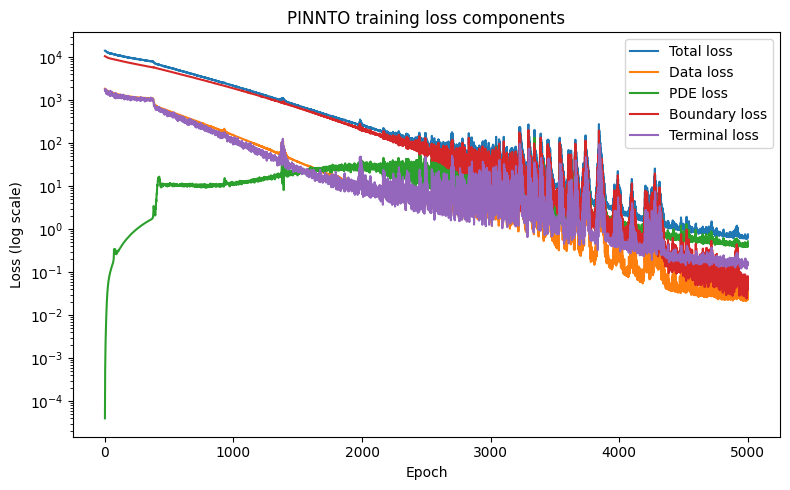

Mean absolute error on grid: 0.11231090873479843


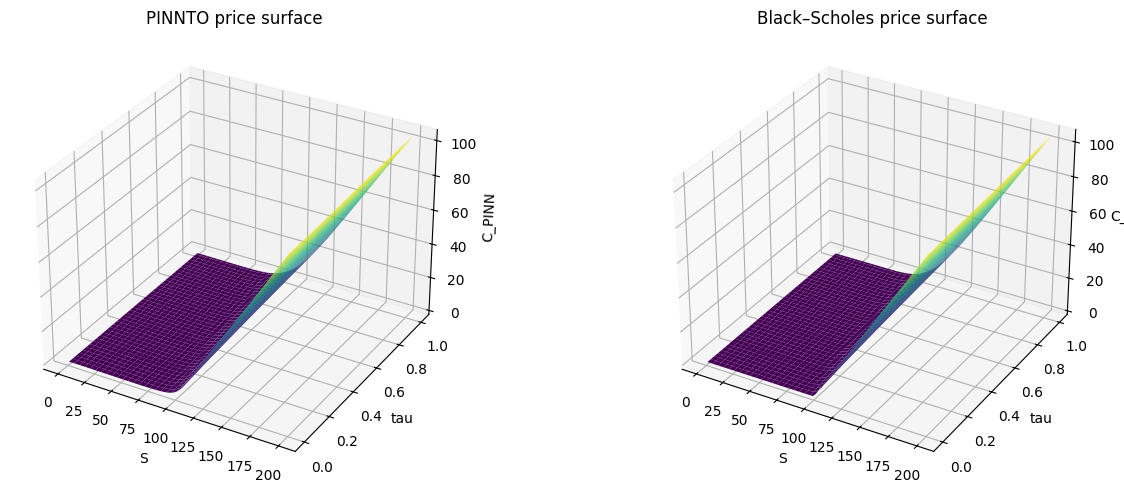

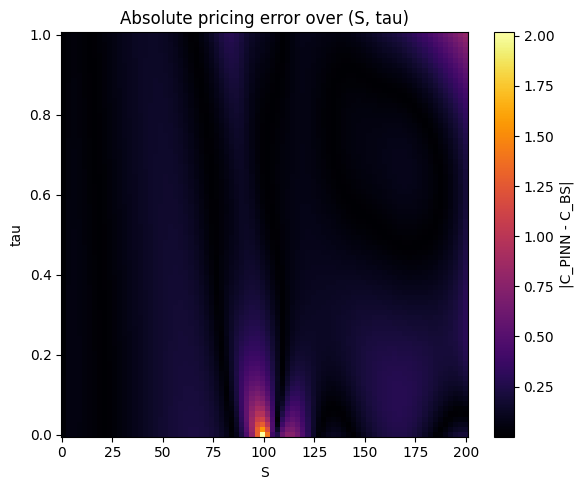

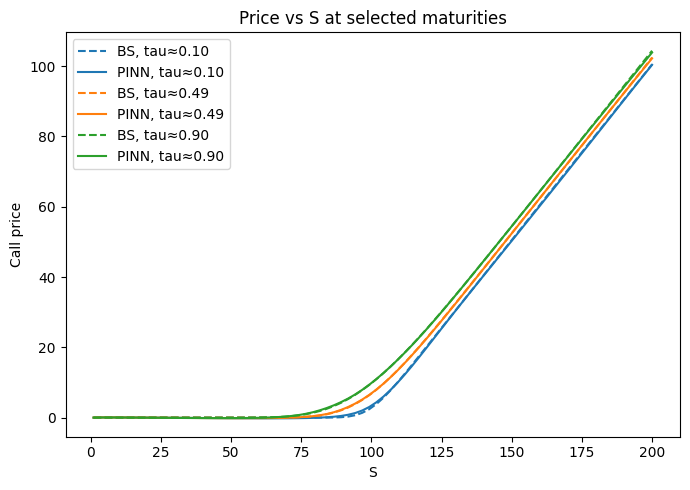

deep_OTM: MAE=0.0859, max_err=0.2352, n=2560
ATM: MAE=0.1645, max_err=2.0172, n=640
deep_ITM: MAE=0.1205, max_err=0.7915, n=2560


In [ ]:
if __name__ == "__main__":
    torch.manual_seed(42)

    bs_params = BSParams(K=100.0, r=0.05, sigma=0.2)
    domain = Domain(S_min=1.0, S_max=200.0, tau_min=0.0, tau_max=1.0)
    loss_weights = LossWeights(data=1.0, pde=1.0, bc=1.0, term=1.0)

    model, history = train_pinn(
        n_epochs=5000,
        n_data=2000,
        n_pde=5000,
        n_term=1000,
        n_bc=1000,
        lr=1e-3,
        bs_params=bs_params,
        domain=domain,
        loss_weights=loss_weights,
    )

    # Figures for paper
    plot_losses(history)

    results = evaluate_on_grid(model, domain, bs_params, n_S=80, n_tau=80)
    mae = results["abs_error"].mean().item()
    print("Mean absolute error on grid:", mae)

    plot_surfaces(results)
    plot_error_heatmap(results)
    plot_slices_vs_S(results, tau_values=[0.1, 0.5, 0.9])
    print_region_error_stats(results, bs_params)


In [ ]:
pip install shap


In [ ]:
import shap

class PINNWrapper:
    def __init__(self, model: PINN):
        self.model = model.eval()

    def __call__(self, X_np: np.ndarray) -> np.ndarray:
        """
        X_np: shape (n, 2) with columns [tau, S].
        Returns predicted prices as numpy array shape (n,).
        """
        X = torch.tensor(X_np, dtype=torch.float32, device=device)
        tau = X[:, 0:1]
        S = X[:, 1:2]
        with torch.no_grad():
            C = self.model(tau, S).cpu().numpy().reshape(-1)
        return C


In [ ]:
def run_shap_analysis(model: PINN,
                      domain: Domain,
                      n_background: int = 500,
                      n_explain: int = 500):
    """
    SHAP analysis for PINNTO.

    Features:
      - 'Time to maturity (years)'   -> tau
      - 'Underlying price'           -> S

    Produces:
      - SHAP summary plot
      - SHAP dependence plot for underlying price
      - SHAP dependence plot for time to maturity
    """
    wrapper = PINNWrapper(model)

    # Background sample (for KernelExplainer)
    S_bg, tau_bg = sample_uniform_2d(
        n_background,
        domain.S_min, domain.S_max,
        domain.tau_min + 1e-3, domain.tau_max
    )
    bg_np = np.concatenate(
        [tau_bg.cpu().numpy(), S_bg.cpu().numpy()],
        axis=1
    )

    # Points to explain
    S_ex, tau_ex = sample_uniform_2d(
        n_explain,
        domain.S_min, domain.S_max,
        domain.tau_min + 1e-3, domain.tau_max
    )
    X_ex = np.concatenate(
        [tau_ex.cpu().numpy(), S_ex.cpu().numpy()],
        axis=1
    )

    # KernelExplainer for arbitrary black-box model
    explainer = shap.KernelExplainer(wrapper, shap.sample(bg_np, 200))
    shap_values = explainer.shap_values(X_ex, nsamples=200)

    # Human-readable feature names
    feature_names = ["Time to maturity (years)", "Underlying price"]

    # --- Figure 1: SHAP summary plot ---
    shap.summary_plot(
        shap_values,
        X_ex,
        feature_names=feature_names,
        show=True
    )

    # --- Figure 2: dependence plot for underlying price ---
    shap.dependence_plot(
        "Underlying price",
        shap_values,
        X_ex,
        feature_names=feature_names,
        show=True,
    )

    # --- Figure 3: dependence plot for time to maturity ---
    shap.dependence_plot(
        "Time to maturity (years)",
        shap_values,
        X_ex,
        feature_names=feature_names,
        show=True,
    )

    return shap_values, X_ex


Epoch     1 | Loss=1.4059e+04 | L_data=1.8355e+03 | L_pde=4.0079e-05 | L_term=1.7358e+03 | L_bc=1.0488e+04
Epoch   500 | Loss=5.7604e+03 | L_data=5.5772e+02 | L_pde=1.0143e+01 | L_term=5.3266e+02 | L_bc=4.6598e+03
Epoch  1000 | Loss=2.1400e+03 | L_data=1.5169e+02 | L_pde=1.1960e+01 | L_term=1.0727e+02 | L_bc=1.8691e+03
Epoch  1500 | Loss=7.4683e+02 | L_data=3.7575e+01 | L_pde=1.9610e+01 | L_term=2.3785e+01 | L_bc=6.6586e+02
Epoch  2000 | Loss=2.6790e+02 | L_data=1.1862e+01 | L_pde=2.4605e+01 | L_term=6.4773e+00 | L_bc=2.2496e+02
Epoch  2500 | Loss=1.1130e+02 | L_data=4.1966e+00 | L_pde=1.2893e+01 | L_term=4.7686e+00 | L_bc=8.9442e+01
Epoch  3000 | Loss=4.4984e+01 | L_data=4.9609e+00 | L_pde=1.5765e+01 | L_term=1.0283e+01 | L_bc=1.3975e+01
Epoch  3500 | Loss=1.0979e+01 | L_data=4.2666e-01 | L_pde=2.3764e+00 | L_term=9.4430e-01 | L_bc=7.2319e+00
Epoch  4000 | Loss=5.8654e+00 | L_data=3.8440e-01 | L_pde=1.3150e+00 | L_term=7.0922e-01 | L_bc=3.4568e+00
Epoch  4500 | Loss=1.0541e+00 | L_dat

Epoch  5000 | Loss=7.5545e-01 | L_data=3.5249e-02 | L_pde=5.1879e-01 | L_term=1.6102e-01 | L_bc=4.0391e-02
Mean absolute error on grid: 0.11231090873479843


  0%|          | 0/500 [00:00<?, ?it/s]

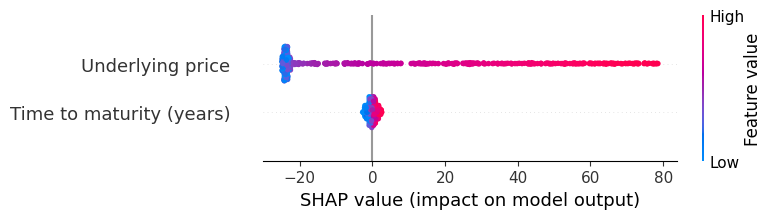

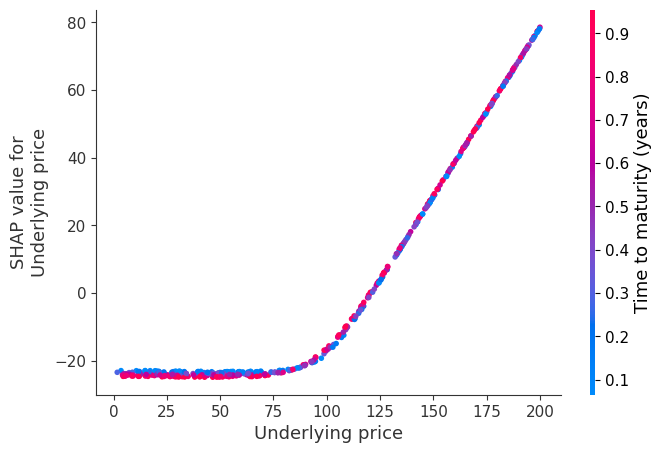

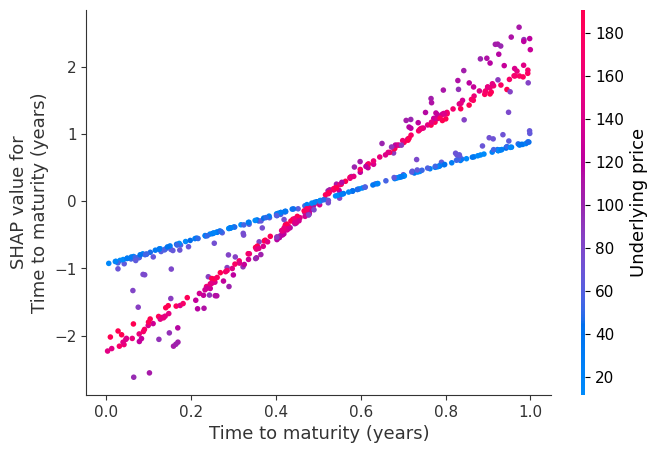

In [ ]:
if __name__ == "__main__":
    torch.manual_seed(42)

    bs_params = BSParams(K=100.0, r=0.05, sigma=0.2)
    domain = Domain(S_min=1.0, S_max=200.0, tau_min=0.0, tau_max=1.0)
    loss_weights = LossWeights(data=1.0, pde=1.0, bc=1.0, term=1.0)

    model, history = train_pinn(
        n_epochs=5000,
        n_data=2000,
        n_pde=5000,
        n_term=1000,
        n_bc=1000,
        lr=1e-3,
        bs_params=bs_params,
        domain=domain,
        loss_weights=loss_weights,
    )

    results = evaluate_on_grid(model, domain, bs_params, n_S=80, n_tau=80)
    print("Mean absolute error on grid:",
          results["abs_error"].mean().item())

    # SHAP analysis (may take a bit of time)
    shap_values, X_ex = run_shap_analysis(
        model,
        domain,
        n_background=500,
        n_explain=500,
    )


Generating 5000 rigorous hold-out points...
Black-Scholes baseline computed in 0.0005 seconds.
PINN Surrogate computed 5000 points in 0.0102 seconds.
Speedup Factor vs Black-Scholes: 0.05x
-------------------------------------------------------
OUT-OF-SAMPLE HOLD-OUT METRICS (PINN vs Black-Scholes)
-------------------------------------------------------
MAE  (Mean Absolute Error)    : 0.113486
RMSE (Root Mean Square Error) : 0.163266
L_inf (Max Absolute Error)    : 1.502832
MAPE (Mean Abs % Error)       : 173056080.0000%
R²   Score                    : 0.999976
-------------------------------------------------------


/tmp/ipython-input-1337679079.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=moneyness_groups, y=abs_errs,


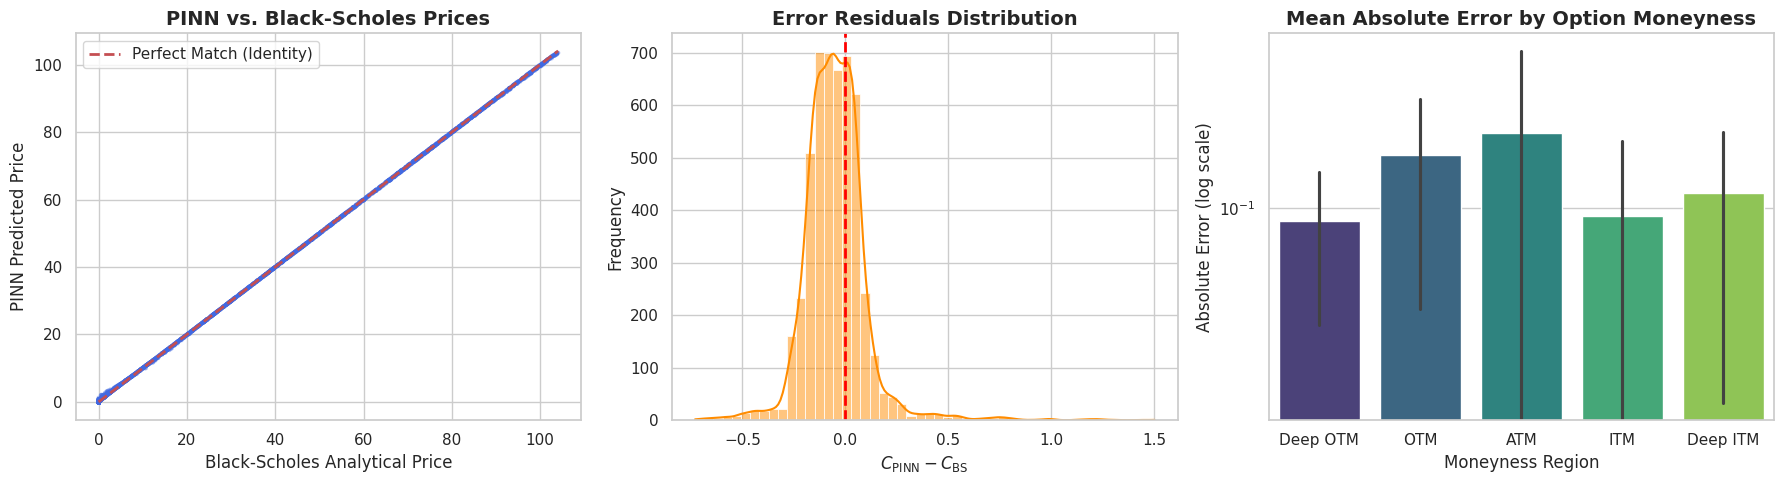

Figure saved as pinnto_publication_graphs.png


In [ ]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, r2_score
from __main__ import *  # imports everything from previous cells

# ---------------------------------------------------------
# 1. Generate Rigorous Hold-out Set using Black-Scholes
# ---------------------------------------------------------
def generate_bs_holdout_set(n_holdout: int, domain: Domain, params: BSParams):
    """
    Generates a rigorous hold-out set completely disjoint from training
    and evaluates it using the closed-form Black-Scholes analytical solution.
    """
    print(f"Generating {n_holdout} rigorous hold-out points...")

    S_holdout, tau_holdout = sample_uniform_2d(
        n_holdout, domain.S_min, domain.S_max, domain.tau_min + 1e-3, domain.tau_max
    )

    start_time = time.time()
    with torch.no_grad():
        K     = torch.full_like(S_holdout, params.K)
        r     = torch.full_like(S_holdout, params.r)
        sigma = torch.full_like(S_holdout, params.sigma)
        C_bs  = black_scholes_call(S_holdout, K, tau_holdout, r, sigma)
    bs_compute_time = time.time() - start_time

    print(f"Black-Scholes baseline computed in {bs_compute_time:.4f} seconds.")
    return S_holdout, tau_holdout, C_bs, bs_compute_time


# ---------------------------------------------------------
# 2. Publication Metrics  (PINN vs Black-Scholes)
# ---------------------------------------------------------
def calculate_publication_metrics(C_pred, C_true):
    pred = C_pred.cpu().numpy().flatten()
    true = C_true.cpu().numpy().flatten()

    mae     = np.mean(np.abs(pred - true))
    rmse    = root_mean_squared_error(true, pred)
    max_err = np.max(np.abs(pred - true))
    r2      = r2_score(true, pred)

    # MAPE — small epsilon prevents div-by-zero for deep OTM options
    eps  = 1e-8
    mape = np.mean(np.abs((true - pred) / (true + eps))) * 100

    print("-" * 55)
    print("OUT-OF-SAMPLE HOLD-OUT METRICS (PINN vs Black-Scholes)")
    print("-" * 55)
    print(f"MAE  (Mean Absolute Error)    : {mae:.6f}")
    print(f"RMSE (Root Mean Square Error) : {rmse:.6f}")
    print(f"L_inf (Max Absolute Error)    : {max_err:.6f}")
    print(f"MAPE (Mean Abs % Error)       : {mape:.4f}%")
    print(f"R²   Score                    : {r2:.6f}")
    print("-" * 55)

    return {
        "mae": mae, "rmse": rmse, "max_err": max_err,
        "mape": mape, "r2": r2,
        "pred": pred, "true": true
    }


# ---------------------------------------------------------
# 3. Publication-Quality Graphs
# ---------------------------------------------------------
def plot_publication_graphs(S_holdout, tau_holdout, metrics_dict, params: BSParams):
    pred      = metrics_dict["pred"]
    true      = metrics_dict["true"]
    S_flat    = S_holdout.cpu().numpy().flatten()
    moneyness = S_flat / params.K
    residuals = pred - true

    sns.set_theme(style="whitegrid")
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # --- Graph 1: Parity Plot (PINN vs Black-Scholes) ---
    axs[0].scatter(true, pred, alpha=0.4, color="royalblue", s=10, edgecolor="none")
    min_val, max_val = true.min(), true.max()
    axs[0].plot([min_val, max_val], [min_val, max_val],
                'r--', lw=2, label="Perfect Match (Identity)")
    axs[0].set_title("PINN vs. Black-Scholes Prices", fontsize=14, fontweight='bold')
    axs[0].set_xlabel("Black-Scholes Analytical Price", fontsize=12)
    axs[0].set_ylabel("PINN Predicted Price", fontsize=12)
    axs[0].legend()

    # --- Graph 2: Residual Distribution ---
    sns.histplot(residuals, bins=50, kde=True, ax=axs[1], color="darkorange")
    axs[1].axvline(0, color='red', linestyle='dashed', linewidth=2)
    axs[1].set_title("Error Residuals Distribution", fontsize=14, fontweight='bold')
    axs[1].set_xlabel(r"$C_{\mathrm{PINN}} - C_{\mathrm{BS}}$", fontsize=12)
    axs[1].set_ylabel("Frequency", fontsize=12)

    # --- Graph 3: MAE by Moneyness Region ---
    conditions = [
        (moneyness < 0.8),
        (moneyness >= 0.8)  & (moneyness < 0.95),
        (moneyness >= 0.95) & (moneyness <= 1.05),
        (moneyness > 1.05)  & (moneyness <= 1.2),
        (moneyness > 1.2)
    ]
    choices         = ['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']
    moneyness_groups = np.select(conditions, choices, default='Unknown')
    abs_errs         = np.abs(residuals)

    sns.barplot(x=moneyness_groups, y=abs_errs,
                order=choices, ax=axs[2],
                palette="viridis", errorbar='sd')
    axs[2].set_title("Mean Absolute Error by Option Moneyness",
                     fontsize=14, fontweight='bold')
    axs[2].set_xlabel("Moneyness Region", fontsize=12)
    axs[2].set_ylabel("Absolute Error (log scale)", fontsize=12)
    axs[2].set_yscale("log")

    plt.tight_layout()
    plt.savefig("pinnto_publication_graphs.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved as pinnto_publication_graphs.png")


# ---------------------------------------------------------
# Execution Block
# ---------------------------------------------------------
if __name__ == "__main__":
    n_holdout = 5000

    # Step 1 — Generate Black-Scholes hold-out baseline
    S_holdout, tau_holdout, C_bs, bs_compute_time = generate_bs_holdout_set(
        n_holdout, domain, bs_params
    )

    # Step 2 — PINN inference and speedup comparison
    start_time = time.time()
    with torch.no_grad():
        C_pinn = model(tau_holdout, S_holdout)
    pinn_compute_time = time.time() - start_time

    print(f"PINN Surrogate computed {n_holdout} points in {pinn_compute_time:.4f} seconds.")
    print(f"Speedup Factor vs Black-Scholes: {bs_compute_time / pinn_compute_time:.2f}x")

    # Step 3 — Metrics
    metrics = calculate_publication_metrics(C_pinn, C_bs)

    # Step 4 — Publication graphs
    plot_publication_graphs(S_holdout, tau_holdout, metrics, bs_params)